In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri/s1/ROIs1970_fall_s1_19_p924.png
/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri/s1/ROIs1868_summer_s1_59_p1060.png
/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri/s1/ROIs1970_fall_s1_29_p181.png
/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri/s1/ROIs1868_summer_s1_59_p771.png
/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri/s1/ROIs1970_fall_s1_113_p275.png
/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri/s1/ROIs1970_fall_s1_133_p912.png
/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri/s1/ROIs1868_summer_s1_59_p1206.png
/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri/s1/ROIs1970_fall_s1_113_p247.png
/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri/s1/ROIs1868_summer_s1_59_p361.png
/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri/s1/ROIs1868_summer_

In [17]:
import tensorflow as tf
from tensorflow.keras import layers
import os
import matplotlib.pyplot as plt

# Define paths
SAR_PATH = '/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri/s1'
COLOR_PATH = '/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri/s2'

# Load and preprocess images
def load_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image)
    image = tf.image.resize(image, (256, 256))
    image = image / 127.5 - 1  # Normalize to [-1, 1]
    return image

def load_images():
    # Get the list of image files from both folders and sort them for consistent pairing
    sar_images_files = sorted(os.listdir(SAR_PATH))[:1000]  # Limit to 1000 images
    color_images_files = sorted(os.listdir(COLOR_PATH))[:1000]  # Limit to 1000 images

    # Load the images
    sar_images = [load_image(os.path.join(SAR_PATH, img)) for img in sar_images_files]
    color_images = [load_image(os.path.join(COLOR_PATH, img)) for img in color_images_files]

    return tf.data.Dataset.from_tensor_slices((sar_images, color_images))

# Define the generator (U-Net)
def build_generator():
    inputs = layers.Input(shape=[256, 256, 1])
    down_stack = [
        downsample(64, 4, apply_batchnorm=False),  # (bs, 128, 128, 64)
        downsample(128, 4),  # (bs, 64, 64, 128)
        downsample(256, 4),  # (bs, 32, 32, 256)
        downsample(512, 4),  # (bs, 16, 16, 512)
        downsample(512, 4),  # (bs, 8, 8, 512)
        downsample(512, 4),  # (bs, 4, 4, 512)
        downsample(512, 4),  # (bs, 2, 2, 512)
        downsample(512, 4),  # (bs, 1, 1, 512)
    ]
    up_stack = [
        upsample(512, 4, apply_dropout=True),  # (bs, 2, 2, 1024)
        upsample(512, 4, apply_dropout=True),  # (bs, 4, 4, 1024)
        upsample(512, 4, apply_dropout=True),  # (bs, 8, 8, 1024)
        upsample(512, 4),  # (bs, 16, 16, 1024)
        upsample(256, 4),  # (bs, 32, 32, 512)
        upsample(128, 4),  # (bs, 64, 64, 256)
        upsample(64, 4),   # (bs, 128, 128, 128)
    ]
    initializer = tf.random_normal_initializer(0., 0.02)
    last = layers.Conv2DTranspose(3, 4, strides=2, padding='same',
                                  kernel_initializer=initializer,
                                  activation='tanh')  # (bs, 256, 256, 3)
    x = inputs
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)
    skips = reversed(skips[:-1])
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers.Concatenate()([x, skip])
    x = last(x)
    return tf.keras.Model(inputs=inputs, outputs=x)

def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))
    if apply_batchnorm:
        result.add(layers.BatchNormalization())
    result.add(layers.LeakyReLU())
    return result

def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2DTranspose(filters, size, strides=2,
                                      padding='same',
                                      kernel_initializer=initializer,
                                      use_bias=False))
    result.add(layers.BatchNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))
    result.add(layers.ReLU())
    return result

# Define the discriminator (PatchGAN)
def build_discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)
    inp = layers.Input(shape=[256, 256, 1], name='input_image')
    tar = layers.Input(shape=[256, 256, 3], name='target_image')
    x = layers.concatenate([inp, tar])
    down1 = downsample(64, 4, False)(x)
    down2 = downsample(128, 4)(down1)
    down3 = downsample(256, 4)(down2)
    zero_pad1 = layers.ZeroPadding2D()(down3)
    conv = layers.Conv2D(512, 4, strides=1,
                         kernel_initializer=initializer,
                         use_bias=False)(zero_pad1)
    batchnorm1 = layers.BatchNormalization()(conv)
    leaky_relu = layers.LeakyReLU()(batchnorm1)
    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)
    last = layers.Conv2D(1, 4, strides=1,
                         kernel_initializer=initializer)(zero_pad2)
    return tf.keras.Model(inputs=[inp, tar], outputs=last)

# Define loss functions and optimizers
loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_obj(tf.ones_like(disc_real_output), disc_real_output)
    generated_loss = loss_obj(tf.zeros_like(disc_generated_output), disc_generated_output)
    total_disc_loss = real_loss + generated_loss
    return total_disc_loss

def generator_loss(disc_generated_output, gen_output, target):
    gan_loss = loss_obj(tf.ones_like(disc_generated_output), disc_generated_output)
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
    total_gen_loss = gan_loss + (100 * l1_loss)
    return total_gen_loss

generator = build_generator()
discriminator = build_discriminator()

generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

# Training loop
@tf.function
def train_step(input_image, target):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(input_image, training=True)
        disc_real_output = discriminator([input_image, target], training=True)
        disc_generated_output = discriminator([input_image, gen_output], training=True)
        gen_loss = generator_loss(disc_generated_output, gen_output, target)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)
    generator_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))
    return gen_loss, disc_loss

# Train the model
def train(dataset, epochs):
    for epoch in range(epochs):
        for input_image, target in dataset:
            gen_loss, disc_loss = train_step(input_image, target)
        print(f'Epoch {epoch+1}, Gen Loss: {gen_loss}, Disc Loss: {disc_loss}')

# Load the dataset with batch size 4
dataset = load_images().batch(4)

# Train the model
train(dataset, epochs=50)

2024-09-08 08:59:22.226057: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_107_1/sequential_44_1/dropout_6_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 1, Gen Loss: 28.24974822998047, Disc Loss: 0.44729721546173096
Epoch 2, Gen Loss: 29.152381896972656, Disc Loss: 0.9086756706237793
Epoch 3, Gen Loss: 29.48600959777832, Disc Loss: 0.9274694323539734
Epoch 4, Gen Loss: 29.403188705444336, Disc Loss: 0.871755063533783
Epoch 5, Gen Loss: 25.33069610595703, Disc Loss: 1.0389354228973389
Epoch 6, Gen Loss: 23.600435256958008, Disc Loss: 1.4857988357543945
Epoch 7, Gen Loss: 21.477249145507812, Disc Loss: 1.582950234413147
Epoch 8, Gen Loss: 20.323535919189453, Disc Loss: 1.8897955417633057
Epoch 9, Gen Loss: 18.72998046875, Disc Loss: 1.4929176568984985
Epoch 10, Gen Loss: 19.39333152770996, Disc Loss: 1.6114938259124756
Epoch 11, Gen Loss: 18.201576232910156, Disc Loss: 1.5557310581207275
Epoch 12, Gen Loss: 16.486169815063477, Disc Loss: 1.1465985774993896
Epoch 13, Gen Loss: 16.421802520751953, Disc Loss: 1.2822093963623047
Epoch 14, Gen Loss: 16.16056251525879, Disc Loss: 1.2174084186553955
Epoch 15, Gen Loss: 14.650594711303711,

In [18]:
# Save the trained generator model
generator.save('pix2pix_generator.h5')
discriminator.save('pix2pix_discriminator.h5')

In [19]:
# Load the saved generator model
generator = tf.keras.models.load_model('pix2pix_generator.h5', compile=False)

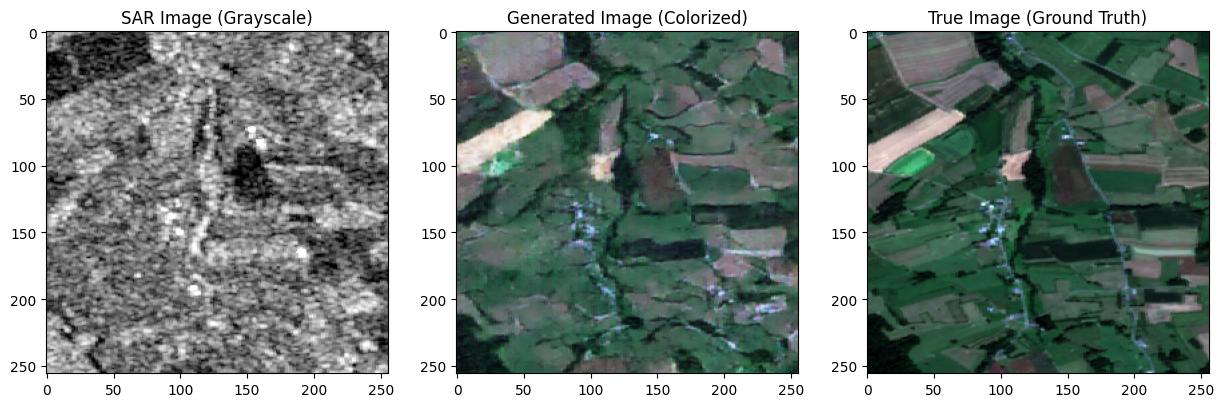

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Define the paths for the 1001st SAR and corresponding color image
SAR_1001_PATH = '/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri/s1/ROIs1868_summer_s1_59_p1002.png'
COLOR_1001_PATH = '/kaggle/input/sentinel12-image-pairs-segregated-by-terrain/v_2/agri/s2/ROIs1868_summer_s2_59_p1002.png'

# Load the 1001st SAR image (grayscale input)
def load_single_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image)
    image = tf.image.resize(image, (256, 256))
    image = image / 127.5 - 1  # Normalize to [-1, 1]
    return tf.expand_dims(image, axis=0)  # Add batch dimension

# Function to test the generator on a single image
def test_single_image(generator, sar_image_path, color_image_path):
    sar_image = load_single_image(sar_image_path)  # Load the SAR image
    generated_image = generator(sar_image, training=False)  # Generate the color image

    # Remove batch dimension for visualization
    sar_image = tf.squeeze(sar_image, axis=0)
    generated_image = tf.squeeze(generated_image, axis=0)

    # Load the true color image for comparison
    true_color_image = load_single_image(color_image_path)
    true_color_image = tf.squeeze(true_color_image, axis=0)

    # Denormalize the generated and true images back to [0, 1] range for visualization
    sar_image = (sar_image + 1) / 2
    generated_image = (generated_image + 1) / 2
    true_color_image = (true_color_image + 1) / 2

    # Plot the results
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title('SAR Image (Grayscale)')
    plt.imshow(sar_image, cmap='gray')
    
    plt.subplot(1, 3, 2)
    plt.title('Generated Image (Colorized)')
    plt.imshow(generated_image)
    
    plt.subplot(1, 3, 3)
    plt.title('True Image (Ground Truth)')
    plt.imshow(true_color_image)
    
    plt.show()

# Load and test the 1001st image
test_single_image(generator, SAR_1001_PATH, COLOR_1001_PATH)
